In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer       # <--- THIS IS THE MISSING LINE
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns


import warnings
warnings.filterwarnings('ignore')

In [3]:
pip install plotly

   ---------------------------------------- 0.0/9.9 MB ? eta -:--:--
   ------ --------------------------------- 1.6/9.9 MB 11.8 MB/s eta 0:00:01
   --------------- ------------------------ 3.9/9.9 MB 10.9 MB/s eta 0:00:01
   -------------------------- ------------- 6.6/9.9 MB 11.3 MB/s eta 0:00:01
   ------------------------------------- -- 9.2/9.9 MB 11.5 MB/s eta 0:00:01
   ---------------------------------------- 9.9/9.9 MB 10.6 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [5]:
df=pd.read_csv("credit_card_fraud_10k.csv")
df

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0
...,...,...,...,...,...,...,...,...,...,...
9995,9996,350.91,22,Food,0,0,99,4,37,0
9996,9997,410.04,5,Clothing,0,0,70,3,25,0
9997,9998,527.75,21,Electronics,0,0,44,2,45,0
9998,9999,91.20,2,Electronics,0,0,38,0,37,0


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   transaction_id       10000 non-null  int64  
 1   amount               10000 non-null  float64
 2   transaction_hour     10000 non-null  int64  
 3   merchant_category    10000 non-null  str    
 4   foreign_transaction  10000 non-null  int64  
 5   location_mismatch    10000 non-null  int64  
 6   device_trust_score   10000 non-null  int64  
 7   velocity_last_24h    10000 non-null  int64  
 8   cardholder_age       10000 non-null  int64  
 9   is_fraud             10000 non-null  int64  
dtypes: float64(1), int64(8), str(1)
memory usage: 851.2 KB


In [7]:
df.head(10)

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
0,1,84.47,22,Electronics,0,0,66,3,40,0
1,2,541.82,3,Travel,1,0,87,1,64,0
2,3,237.01,17,Grocery,0,0,49,1,61,0
3,4,164.33,4,Grocery,0,1,72,3,34,0
4,5,30.53,15,Food,0,0,79,0,44,0
5,6,30.53,13,Clothing,0,0,90,2,46,0
6,7,10.77,18,Travel,0,0,48,1,28,0
7,8,362.02,13,Electronics,0,0,68,1,40,0
8,9,165.43,8,Grocery,0,0,80,0,21,0
9,10,221.63,5,Grocery,0,0,59,1,34,0


In [8]:
df.tail(10)

,transaction_id,amount,transaction_hour,merchant_category,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
9990,9991,107.74,12,Travel,1,0,26,2,39,0
9991,9992,70.78,18,Clothing,0,0,67,1,40,0
9992,9993,114.66,20,Travel,0,0,64,2,51,0
9993,9994,307.41,0,Grocery,0,1,92,1,26,0
9994,9995,23.96,22,Food,0,0,28,2,19,0
9995,9996,350.91,22,Food,0,0,99,4,37,0
9996,9997,410.04,5,Clothing,0,0,70,3,25,0
9997,9998,527.75,21,Electronics,0,0,44,2,45,0
9998,9999,91.20,2,Electronics,0,0,38,0,37,0
9999,10000,44.06,2,Clothing,0,0,38,0,66,0


In [9]:
df.describe()

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age,is_fraud
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,5000.50000,175.949849,11.593300,0.097800,0.085700,61.798900,2.008900,43.468700,0.015100
std,2886.89568,175.392827,6.922708,0.297059,0.279935,21.487053,1.432559,14.979147,0.121957
min,1.00000,0.000000,0.000000,0.000000,0.000000,25.000000,0.000000,18.000000,0.000000
25%,2500.75000,50.905000,6.000000,0.000000,0.000000,43.000000,1.000000,30.000000,0.000000
50%,5000.50000,122.095000,12.000000,0.000000,0.000000,62.000000,2.000000,44.000000,0.000000
75%,7500.25000,242.480000,18.000000,0.000000,0.000000,80.000000,3.000000,56.000000,0.000000
max,10000.00000,1471.040000,23.000000,1.000000,1.000000,99.000000,9.000000,69.000000,1.000000


In [10]:
df.describe(include='O')

,merchant_category
count,10000
unique,5
top,Food
freq,2093


In [11]:
df.isna().sum()

transaction_id         0
amount                 0
transaction_hour       0
merchant_category      0
foreign_transaction    0
location_mismatch      0
device_trust_score     0
velocity_last_24h      0
cardholder_age         0
is_fraud               0
dtype: int64

In [12]:
df.duplicated()

0       False
1       False
2       False
3       False
4       False
        ...  
9995    False
9996    False
9997    False
9998    False
9999    False
Length: 10000, dtype: bool

In [13]:
df.nunique()

transaction_id         10000
amount                  8788
transaction_hour          24
merchant_category          5
foreign_transaction        2
location_mismatch          2
device_trust_score        75
velocity_last_24h         10
cardholder_age            52
is_fraud                   2
dtype: int64

Fraud Rate: 1.51%


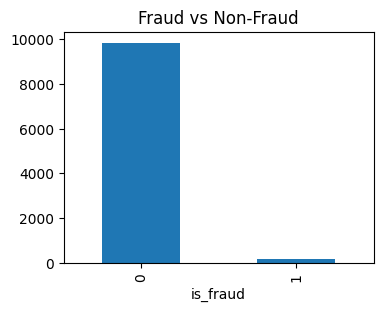

In [14]:
fraud_counts = df["is_fraud"].value_counts()
fraud_rate = df["is_fraud"].mean() * 100

print(f"Fraud Rate: {fraud_rate:.2f}%")

plt.figure(figsize=(4,3))
fraud_counts.plot(kind="bar")
plt.title("Fraud vs Non-Fraud")
plt.show()

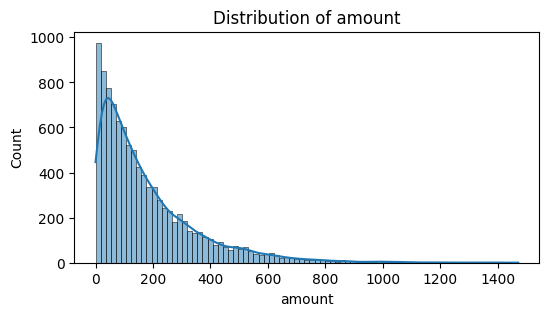

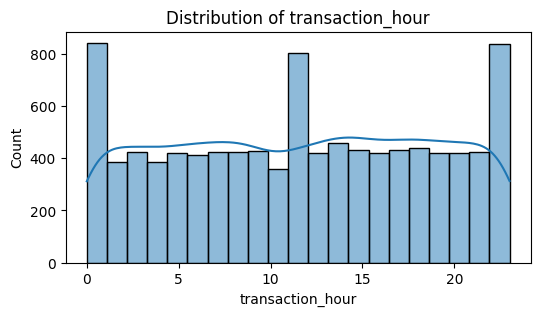

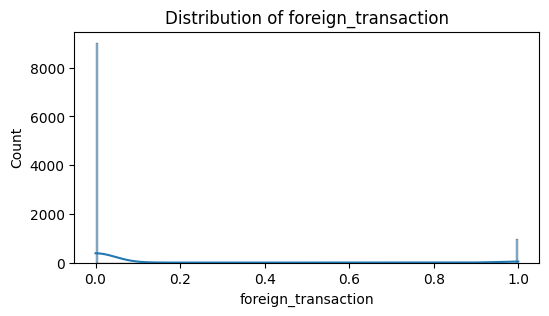

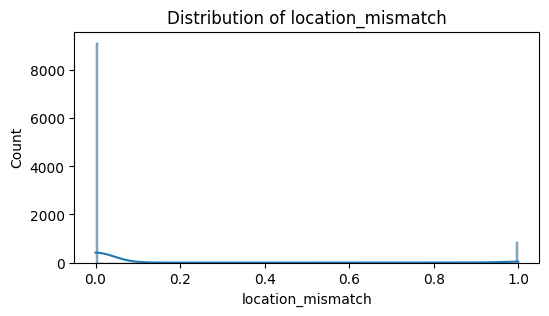

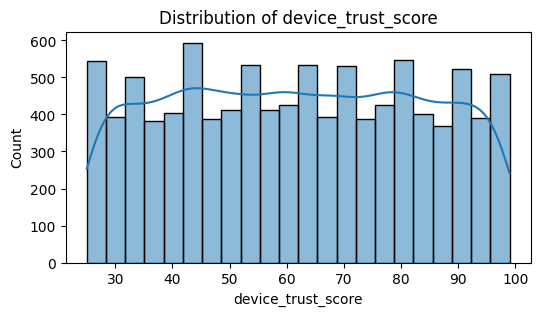

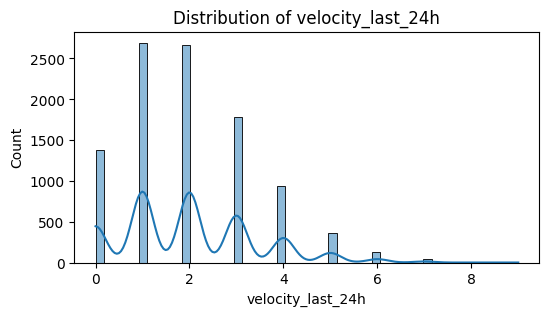

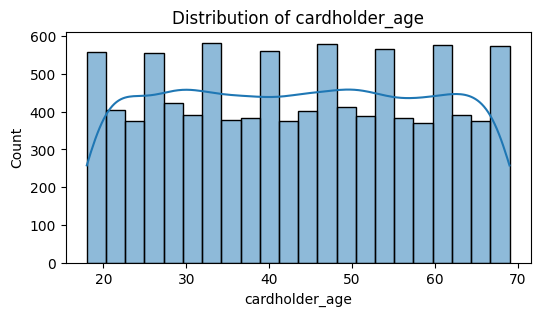

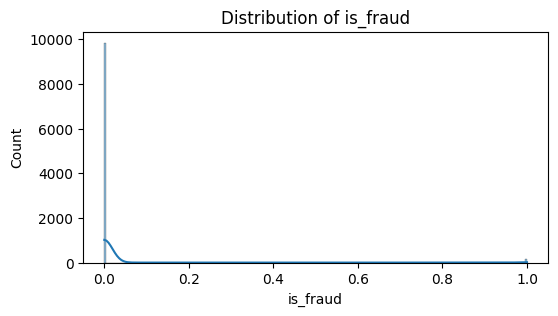

In [15]:
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    if col != "transaction_id":
        plt.figure(figsize=(6,3))
        sns.histplot(df[col], kde=True)
        plt.title(f"Distribution of {col}")
        plt.show()

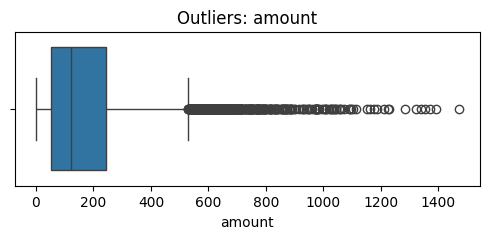

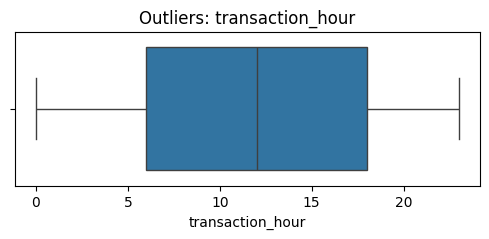

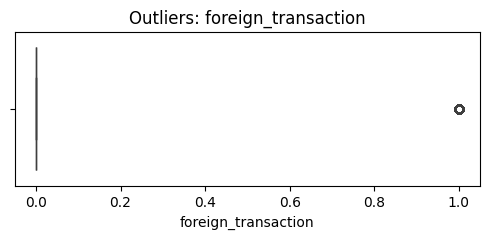

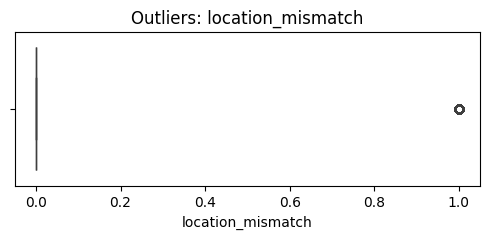

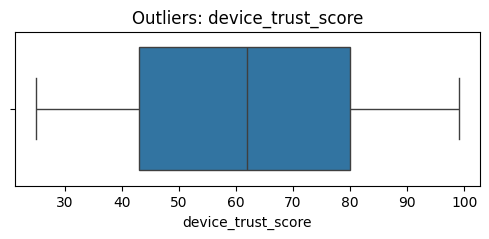

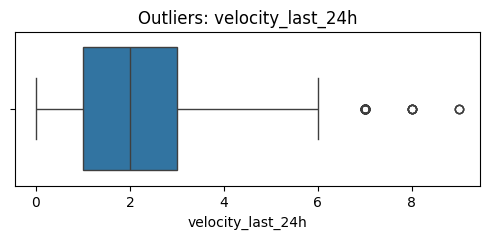

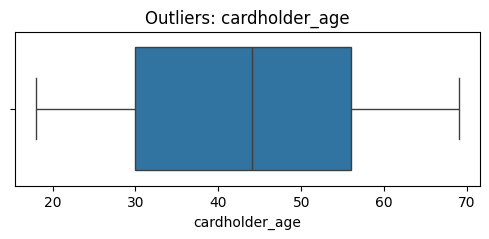

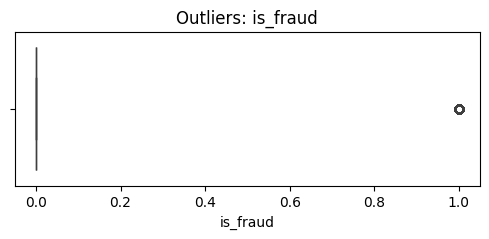

In [16]:
for col in num_cols:
    if col != "transaction_id":
        plt.figure(figsize=(6,2))
        sns.boxplot(x=df[col])
        plt.title(f"Outliers: {col}")
        plt.show()

In [17]:
group_stats = df.groupby("is_fraud").mean(numeric_only=True)
group_stats

,transaction_id,amount,transaction_hour,foreign_transaction,location_mismatch,device_trust_score,velocity_last_24h,cardholder_age
is_fraud,,,,,,,,
0,5004.129861,175.333015,11.712154,0.090974,0.079704,62.165804,1.990557,43.469794
1,4763.741722,216.182980,3.841060,0.543046,0.476821,37.867550,3.205298,43.397351



Fraud % by foreign_transaction:
 is_fraud                 0     1
foreign_transaction             
0                    99.24  0.76
1                    91.62  8.38


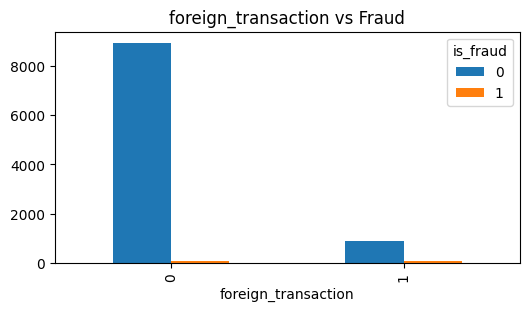


Fraud % by location_mismatch:
 is_fraud               0     1
location_mismatch             
0                  99.14  0.86
1                  91.60  8.40


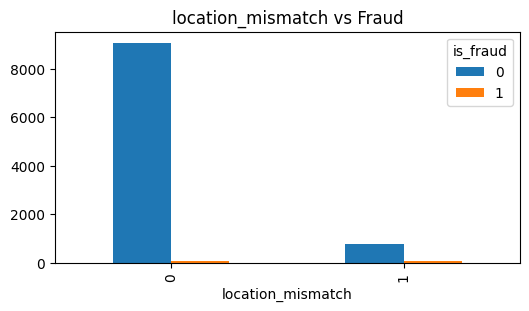

In [18]:
binary_cols = ["foreign_transaction", "location_mismatch"]

for col in binary_cols:
    table = pd.crosstab(df[col], df["is_fraud"], normalize="index") * 100
    print(f"\nFraud % by {col}:\n", table.round(2))

    pd.crosstab(df[col], df["is_fraud"]).plot(kind="bar", figsize=(6,3))
    plt.title(f"{col} vs Fraud")
    plt.show()

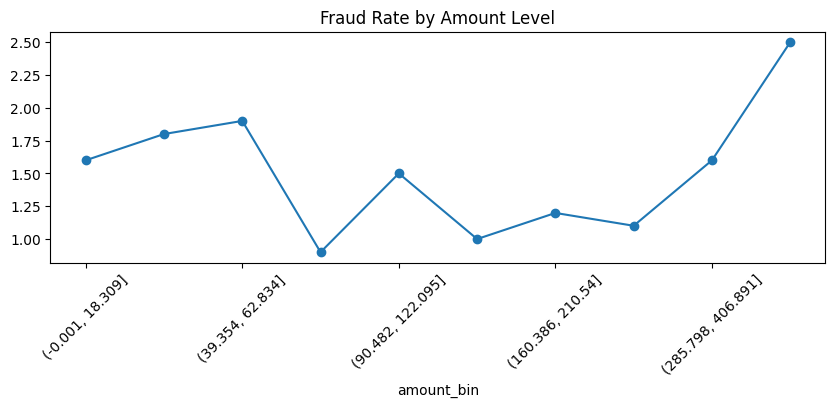

In [19]:
df["amount_bin"] = pd.qcut(df["amount"], q=10)

amount_risk = df.groupby("amount_bin")["is_fraud"].mean() * 100

plt.figure(figsize=(10,3))
amount_risk.plot(marker="o")
plt.title("Fraud Rate by Amount Level")
plt.xticks(rotation=45)
plt.show()

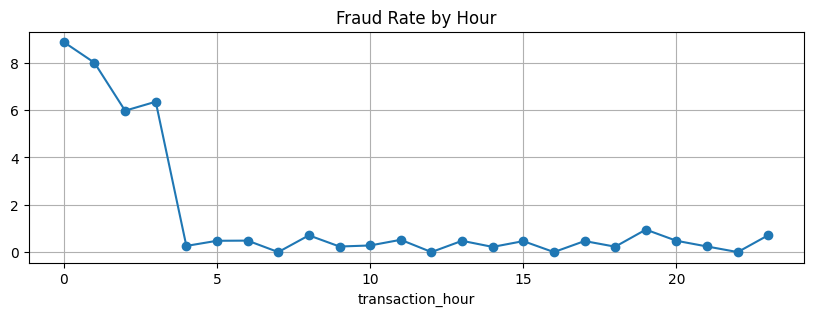

In [20]:
hour_pattern = df.groupby("transaction_hour")["is_fraud"].mean() * 100

plt.figure(figsize=(10,3))
hour_pattern.plot(marker="o")
plt.title("Fraud Rate by Hour")
plt.grid(True)
plt.show()

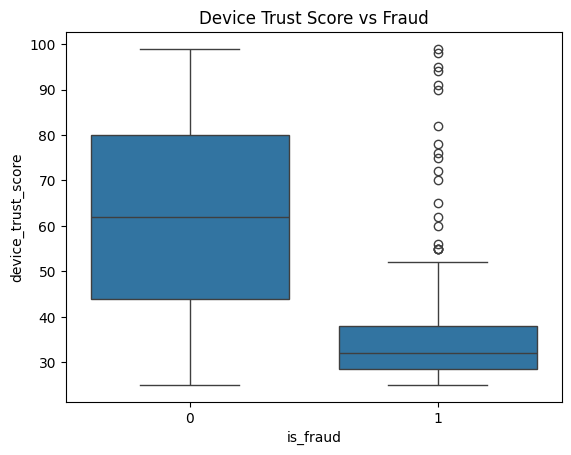

In [21]:
sns.boxplot(data=df, x="is_fraud", y="device_trust_score")
plt.title("Device Trust Score vs Fraud")
plt.show()

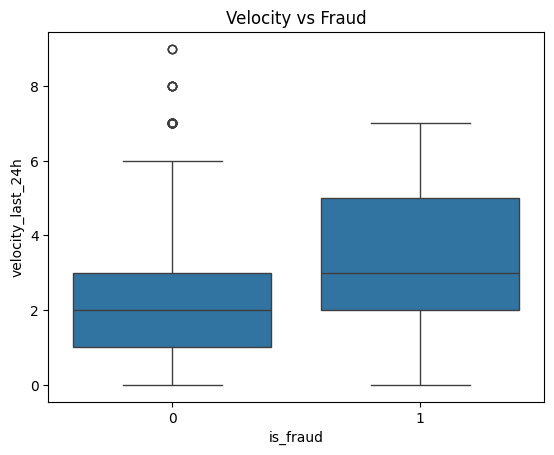

In [22]:
sns.boxplot(data=df, x="is_fraud", y="velocity_last_24h")
plt.title("Velocity vs Fraud")
plt.show()

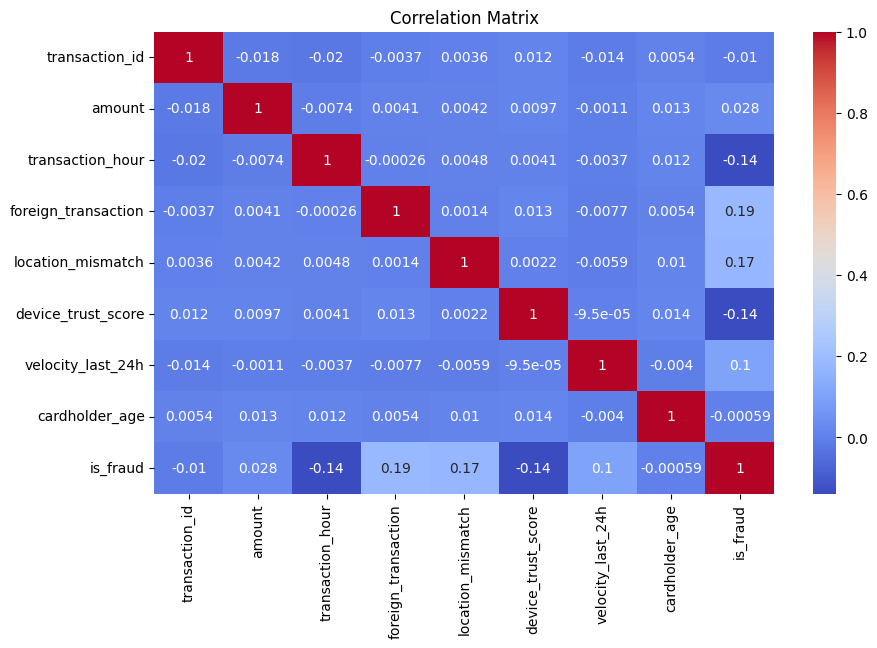

In [23]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

In [24]:
df2 = df.copy()

vel_thr = df2["velocity_last_24h"].quantile(0.9)
trust_thr = df2["device_trust_score"].quantile(0.1)

df2["risk_score"] = 0
df2["risk_score"] += (df2["foreign_transaction"]==1).astype(int)
df2["risk_score"] += (df2["location_mismatch"]==1).astype(int)
df2["risk_score"] += (df2["velocity_last_24h"]>=vel_thr).astype(int)
df2["risk_score"] += (df2["device_trust_score"]<=trust_thr).astype(int)

risk_analysis = df2.groupby("risk_score")["is_fraud"].mean()*100
risk_analysis

risk_score
0      0.031913
1      0.894855
2     16.283186
3     73.684211
4    100.000000
Name: is_fraud, dtype: float64

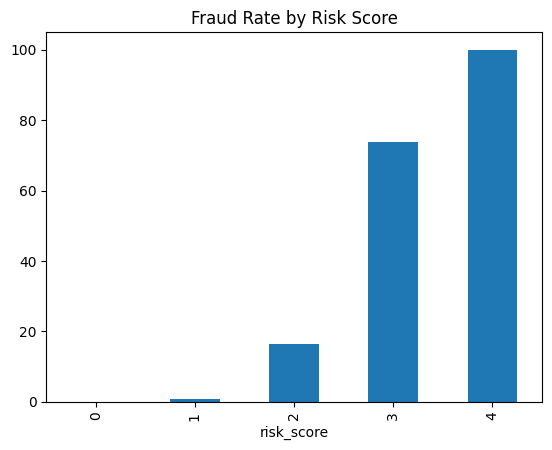

In [25]:
risk_analysis.plot(kind="bar")
plt.title("Fraud Rate by Risk Score")
plt.show()

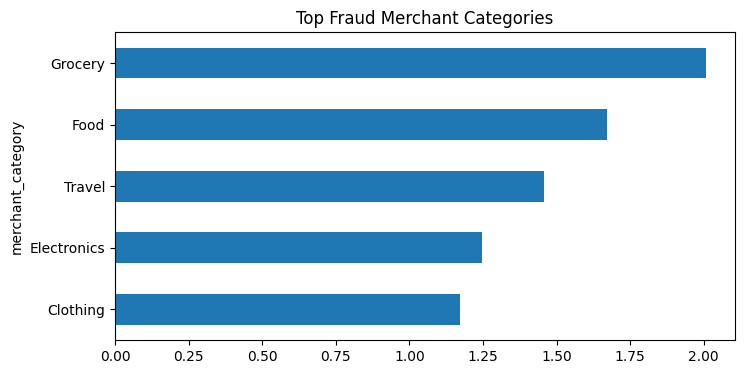

In [26]:
cat_risk = df.groupby("merchant_category")["is_fraud"].mean().sort_values(ascending=False)*100

top10 = cat_risk.head(10)

top10.sort_values().plot(kind="barh", figsize=(8,4))
plt.title("Top Fraud Merchant Categories")
plt.show()

In [29]:
X = df.drop(columns=['transaction_id', 'is_fraud', 'amount_bin'], errors='ignore')
y = df['is_fraud']

# Dynamically encode 'merchant_category' into binary format columns
categorical_cols = ['merchant_category']
numerical_cols = [col for col in X.columns if col not in categorical_cols]

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_cols),
        ('num', 'passthrough', numerical_cols)
    ])

In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Apply preprocessing transformations
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

In [32]:
from xgboost import XGBClassifier  # <--- ADD THIS LINE HERE

# Now the rest of your cell will run perfectly:
num_neg = np.sum(y_train == 0)
num_pos = np.sum(y_train == 1)
scale_weight_ratio = num_neg / num_pos

print(f"Calculated weight penalty factor for imbalanced fraud data: {scale_weight_ratio:.2f}")

ml_model = XGBClassifier(
    n_estimators=150,
    max_depth=5,
    learning_rate=0.1,
    scale_pos_weight=scale_weight_ratio,
    random_state=42,
    eval_metric='logloss'
)

ml_model.fit(X_train_processed, y_train)

Calculated weight penalty factor for imbalanced fraud data: 65.12


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 


--- CONFUSION MATRIX ---
[[1970    0]
 [   0   30]]

--- PERFORMANCE METRICS (CLASSIFICATION REPORT) ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1970
           1       1.00      1.00      1.00        30

    accuracy                           1.00      2000
   macro avg       1.00      1.00      1.00      2000
weighted avg       1.00      1.00      1.00      2000



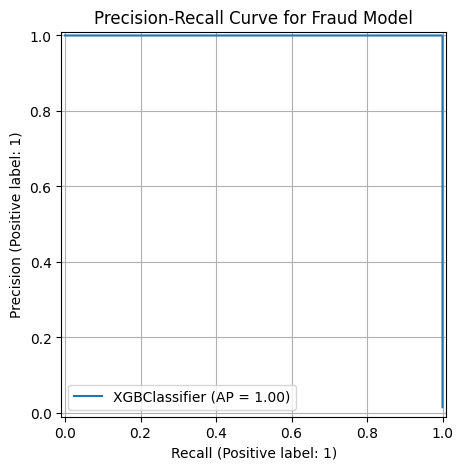

In [34]:
from sklearn.metrics import confusion_matrix, classification_report, PrecisionRecallDisplay

# Now the rest of your original cell code will work perfectly:
y_pred = ml_model.predict(X_test_processed)

print("\n--- CONFUSION MATRIX ---")
print(confusion_matrix(y_test, y_pred))

print("\n--- PERFORMANCE METRICS (CLASSIFICATION REPORT) ---")
print(classification_report(y_test, y_pred))

# Plot Precision-Recall curve to visualize actual model stability
plt.figure(figsize=(7, 5))
PrecisionRecallDisplay.from_estimator(ml_model, X_test_processed, y_test, ax=plt.gca())
plt.title("Precision-Recall Curve for Fraud Model")
plt.grid(True)
plt.show()

In [36]:
import joblib  # <--- ADD THIS LINE HERE

# Now your original code will save the files perfectly:
joblib.dump(preprocessor, 'fraud_preprocessor.joblib')
joblib.dump(ml_model, 'best_fraud_xgboost_model.joblib')

['best_fraud_xgboost_model.joblib']

In [38]:
from flask import Flask, render_template, request
import pandas as pd
import joblib
import numpy as np

app = Flask(__name__)

# Load the saved model and preprocessor artifacts
try:
    preprocessor = joblib.load('fraud_preprocessor.joblib')
    model = joblib.load('best_fraud_xgboost_model.joblib')
except FileNotFoundError:
    print("❌ Error: Could not find model or preprocessor files. Make sure they are in the same folder as app.py")

@app.route('/', methods=['GET', 'POST'])
def home():
    prediction_text = None
    probability_text = None
    alert_class = ""
    
    if request.method == 'POST':
        try:
            # 1. Capture form data submitted from the UI HTML page
            form_data = {
                'amount': float(request.form['amount']),
                'transaction_hour': int(request.form['transaction_hour']),
                'merchant_category': request.form['merchant_category'],
                'foreign_transaction': int(request.form['foreign_transaction']),
                'location_mismatch': int(request.form['location_mismatch']),
                'device_trust_score': int(request.form['device_trust_score']),
                'velocity_last_24h': int(request.form['velocity_last_24h']),
                'cardholder_age': int(request.form['cardholder_age'])
            }
            
            # 2. Convert raw form entries into a Pandas DataFrame format
            input_df = pd.DataFrame([form_data])
            
            # 3. Process the raw fields using your fitted pipeline transformer
            processed_input = preprocessor.transform(input_df)
            
            # 4. Generate prediction arrays and confidence statistics
            prob = model.predict_proba(processed_input)[0][1] # Probability of being fraud
            pred = model.predict(processed_input)[0]          # 0 or 1
            
            # 5. Build dynamic text outputs for your front-end display
            probability_text = f"Fraud Risk Confidence: {prob * 100:.2f}%"
            
            if pred == 1:
                prediction_text = "🚨 TRANSACTION BLOCKED: High Risk of Fraud detected!"
                alert_class = "danger"
            else:
                prediction_text = "✅ TRANSACTION APPROVED: Low Risk transaction profile."
                alert_class = "success"
                
        except Exception as e:
            prediction_text = f"Error processing request: {str(e)}"
            alert_class = "warning"

    return render_template('index1.html', 
                           prediction=prediction_text, 
                           probability=probability_text, 
                           alert_class=alert_class)

if __name__ == '__main__':
    app.run(debug=True)

 * Serving Flask app '__main__'
 * Debug mode: on


 * Running on http://127.0.0.1:5000
Press CTRL+C to quit
 * Restarting with watchdog (windowsapi)


SystemExit: 1